In [1]:
import pandas as pd

C:\Users\Ryzen\AppData\Local\Temp\ipykernel_22984\4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
city=pd.read_csv(r'city.csv')
customers=pd.read_csv(r'customers.csv')
products=pd.read_csv(r'products.csv')
sales=pd.read_csv(r'sales.csv')


In [3]:
sales

,sale_id,sale_date,product_id,customer_id,total,rating
0,2609,2023-09-01,24,1,500,5
1,2716,2023-09-04,24,1,500,4
2,3025,2023-09-14,24,1,500,5
3,3581,2023-10-02,4,1,600,5
4,4504,2023-11-04,5,1,450,4
...,...,...,...,...,...,...
10383,4663,2023-11-09,7,497,1500,3
10384,7315,2024-02-09,4,497,600,3
10385,8718,2024-03-26,4,497,600,3
10386,3526,2023-09-30,24,497,500,3


# 2. **Total Revenue from Coffee Sales**  
   What is the total revenue generated from coffee sales across all cities in the last quarter of 2023?


In [4]:
temp=pd.merge(customers,sales,how='inner',on='customer_id')
temp

,customer_id,customer_name,city_id,sale_id,sale_date,product_id,total,rating
0,1,Aarav Agarwal,1,2609,2023-09-01,24,500,5
1,1,Aarav Agarwal,1,2716,2023-09-04,24,500,4
2,1,Aarav Agarwal,1,3025,2023-09-14,24,500,5
3,1,Aarav Agarwal,1,3581,2023-10-02,4,600,5
4,1,Aarav Agarwal,1,4504,2023-11-04,5,450,4
...,...,...,...,...,...,...,...,...
10383,497,Anushka Verma,14,4663,2023-11-09,7,1500,3
10384,497,Anushka Verma,14,7315,2024-02-09,4,600,3
10385,497,Anushka Verma,14,8718,2024-03-26,4,600,3
10386,497,Anushka Verma,14,3526,2023-09-30,24,500,3


In [5]:
tem=temp[(temp['sale_date']>='2023-10-01')&(temp['sale_date']<='2023-12-31')]

In [6]:
tem

,customer_id,customer_name,city_id,sale_id,sale_date,product_id,total,rating
3,1,Aarav Agarwal,1,3581,2023-10-02,4,600,5
4,1,Aarav Agarwal,1,4504,2023-11-04,5,450,4
5,1,Aarav Agarwal,1,5079,2023-11-23,8,750,5
6,1,Aarav Agarwal,1,5452,2023-12-05,9,700,4
25,1,Aarav Agarwal,1,5913,2023-12-22,14,320,4
...,...,...,...,...,...,...,...,...
10374,496,Priya Chaudhary,14,3622,2023-10-03,7,1500,5
10375,496,Priya Chaudhary,14,3848,2023-10-11,5,450,3
10376,496,Priya Chaudhary,14,5065,2023-11-23,1,350,4
10383,497,Anushka Verma,14,4663,2023-11-09,7,1500,3


In [7]:
tem=temp.merge(city,how='inner',on='city_id')

In [8]:
tem

,customer_id,customer_name,city_id,sale_id,sale_date,product_id,total,rating,city_name,population,estimated_rent,city_rank
0,1,Aarav Agarwal,1,2609,2023-09-01,24,500,5,Bangalore,12300000,29700,1
1,1,Aarav Agarwal,1,2716,2023-09-04,24,500,4,Bangalore,12300000,29700,1
2,1,Aarav Agarwal,1,3025,2023-09-14,24,500,5,Bangalore,12300000,29700,1
3,1,Aarav Agarwal,1,3581,2023-10-02,4,600,5,Bangalore,12300000,29700,1
4,1,Aarav Agarwal,1,4504,2023-11-04,5,450,4,Bangalore,12300000,29700,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10383,497,Anushka Verma,14,4663,2023-11-09,7,1500,3,Indore,3300000,6300,14
10384,497,Anushka Verma,14,7315,2024-02-09,4,600,3,Indore,3300000,6300,14
10385,497,Anushka Verma,14,8718,2024-03-26,4,600,3,Indore,3300000,6300,14
10386,497,Anushka Verma,14,3526,2023-09-30,24,500,3,Indore,3300000,6300,14


In [9]:
tem.groupby(['city_name'])['total'].sum()

city_name
Ahmedabad     137690
Bangalore     860110
Chennai       944120
Delhi         750420
Hyderabad     131520
Indore        138590
Jaipur        803450
Kanpur        213550
Kolkata       171460
Lucknow       109400
Mumbai        235000
Nagpur        140050
Pune         1258290
Surat         176540
Name: total, dtype: int64

# 3. **Sales Count for Each Product**  
   How many units of each coffee product have been sold?

In [10]:
sales

,sale_id,sale_date,product_id,customer_id,total,rating
0,2609,2023-09-01,24,1,500,5
1,2716,2023-09-04,24,1,500,4
2,3025,2023-09-14,24,1,500,5
3,3581,2023-10-02,4,1,600,5
4,4504,2023-11-04,5,1,450,4
...,...,...,...,...,...,...
10383,4663,2023-11-09,7,497,1500,3
10384,7315,2024-02-09,4,497,600,3
10385,8718,2024-03-26,4,497,600,3
10386,3526,2023-09-30,24,497,500,3


In [11]:
products

,product_id,product_name,price
0,1,Ground Espresso Coffee (250g),350
1,2,Cold Brew Coffee Pack (6 Bottles),900
2,3,Instant Coffee Powder (100g),250
3,4,Coffee Beans (500g),600
4,5,Coffee Drip Bags (10 Bags),450
5,6,French Press Coffee Set,1200
6,7,Specialty Coffee Subscription,1500
7,8,Flavored Coffee Pods (Pack of 10),750
8,9,Organic Green Coffee Beans (500g),700
9,10,Coffee Gift Hamper,1800


In [12]:
each=pd.merge(sales,products,how='inner',on='product_id')
each

,sale_id,sale_date,product_id,customer_id,total,rating,product_name,price
0,2609,2023-09-01,24,1,500,5,Tote Bag with Coffee Design,500
1,2716,2023-09-04,24,1,500,4,Tote Bag with Coffee Design,500
2,3025,2023-09-14,24,1,500,5,Tote Bag with Coffee Design,500
3,3581,2023-10-02,4,1,600,5,Coffee Beans (500g),600
4,4504,2023-11-04,5,1,450,4,Coffee Drip Bags (10 Bags),450
...,...,...,...,...,...,...,...,...
10383,4663,2023-11-09,7,497,1500,3,Specialty Coffee Subscription,1500
10384,7315,2024-02-09,4,497,600,3,Coffee Beans (500g),600
10385,8718,2024-03-26,4,497,600,3,Coffee Beans (500g),600
10386,3526,2023-09-30,24,497,500,3,Tote Bag with Coffee Design,500


In [13]:
each.groupby(['product_name'])['sale_id'].count()

product_name
Caramel Syrup (250ml)                   96
Coffee Art Print                       296
Coffee Bean Storage Canister            89
Coffee Beans (500g)                   1218
Coffee Drip Bags (10 Bags)             289
Coffee Gift Hamper                     270
Coffee Mug (Ceramic)                    73
Coffee Plant Kit (DIY)                  91
Coffee Recipe Book                      88
Coffee-Themed Notebook                  76
Coffee-Themed T-Shirt                   82
Cold Brew Coffee Pack (6 Bottles)     1326
Cold Brew Concentrate (500ml)          312
Customizable Coffee Coaster Set        258
Flavored Coffee Pods (Pack of 10)      295
French Press Coffee Set                257
Glass Coffee Jar (500ml)                77
Ground Espresso Coffee (250g)         1271
Instant Coffee Powder (100g)          1226
Insulated Travel Mug                   273
Mocha Flavored Coffee Mix (200g)        86
Organic Green Coffee Beans (500g)      307
Personalized Coffee Spoon               8

# 4. **Average Sales Amount per City**  
   What is the average sales amount per customer in each city?

In [14]:
tem=temp.merge(city,how='inner',on='city_id')

In [15]:
ab=tem.groupby(['customer_name','city_name'])['total'].mean()
ab

customer_name  city_name
Aarav Agarwal  Bangalore    541.875000
Aarav Chopra   Chennai      615.333333
Aarav Desai    Delhi        610.000000
Aarav Gupta    Delhi        560.000000
Aarav Joshi    Jaipur       537.368421
                               ...    
Vivaan Sharma  Kolkata      687.500000
Vivaan Shukla  Delhi        648.421053
Vivaan Singh   Pune         646.744186
Vivaan Sinha   Pune         537.608696
Vivaan Verma   Mumbai       406.250000
Name: total, Length: 489, dtype: float64

# 6. **Top Selling Products by City**  
   What are the top 3 selling products in each city based on sales volume?

In [16]:
tem

,customer_id,customer_name,city_id,sale_id,sale_date,product_id,total,rating,city_name,population,estimated_rent,city_rank
0,1,Aarav Agarwal,1,2609,2023-09-01,24,500,5,Bangalore,12300000,29700,1
1,1,Aarav Agarwal,1,2716,2023-09-04,24,500,4,Bangalore,12300000,29700,1
2,1,Aarav Agarwal,1,3025,2023-09-14,24,500,5,Bangalore,12300000,29700,1
3,1,Aarav Agarwal,1,3581,2023-10-02,4,600,5,Bangalore,12300000,29700,1
4,1,Aarav Agarwal,1,4504,2023-11-04,5,450,4,Bangalore,12300000,29700,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10383,497,Anushka Verma,14,4663,2023-11-09,7,1500,3,Indore,3300000,6300,14
10384,497,Anushka Verma,14,7315,2024-02-09,4,600,3,Indore,3300000,6300,14
10385,497,Anushka Verma,14,8718,2024-03-26,4,600,3,Indore,3300000,6300,14
10386,497,Anushka Verma,14,3526,2023-09-30,24,500,3,Indore,3300000,6300,14


In [17]:
temper=tem.merge(products,how='inner',on='product_id')

In [18]:
temper

,customer_id,customer_name,city_id,sale_id,sale_date,product_id,total,rating,city_name,population,estimated_rent,city_rank,product_name,price
0,1,Aarav Agarwal,1,2609,2023-09-01,24,500,5,Bangalore,12300000,29700,1,Tote Bag with Coffee Design,500
1,1,Aarav Agarwal,1,2716,2023-09-04,24,500,4,Bangalore,12300000,29700,1,Tote Bag with Coffee Design,500
2,1,Aarav Agarwal,1,3025,2023-09-14,24,500,5,Bangalore,12300000,29700,1,Tote Bag with Coffee Design,500
3,1,Aarav Agarwal,1,3581,2023-10-02,4,600,5,Bangalore,12300000,29700,1,Coffee Beans (500g),600
4,1,Aarav Agarwal,1,4504,2023-11-04,5,450,4,Bangalore,12300000,29700,1,Coffee Drip Bags (10 Bags),450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10383,497,Anushka Verma,14,4663,2023-11-09,7,1500,3,Indore,3300000,6300,14,Specialty Coffee Subscription,1500
10384,497,Anushka Verma,14,7315,2024-02-09,4,600,3,Indore,3300000,6300,14,Coffee Beans (500g),600
10385,497,Anushka Verma,14,8718,2024-03-26,4,600,3,Indore,3300000,6300,14,Coffee Beans (500g),600
10386,497,Anushka Verma,14,3526,2023-09-30,24,500,3,Indore,3300000,6300,14,Tote Bag with Coffee Design,500


In [29]:
temper.groupby(['city_name','product_name'])['sale_id'].count().sort_values(ascending=False).groupby('city_name').head(3).sort_index(level='city_name')


city_name  product_name                     
Ahmedabad  Coffee Beans (500g)                   35
           Cold Brew Coffee Pack (6 Bottles)     40
           Instant Coffee Powder (100g)          26
Bangalore  Cold Brew Coffee Pack (6 Bottles)    197
           Ground Espresso Coffee (250g)        167
           Instant Coffee Powder (100g)         150
Chennai    Coffee Beans (500g)                  181
           Cold Brew Coffee Pack (6 Bottles)    192
           Instant Coffee Powder (100g)         172
Delhi      Coffee Beans (500g)                  161
           Ground Espresso Coffee (250g)        183
           Instant Coffee Powder (100g)         170
Hyderabad  Cold Brew Coffee Pack (6 Bottles)     28
           Ground Espresso Coffee (250g)         27
           Instant Coffee Powder (100g)          36
Indore     Cold Brew Coffee Pack (6 Bottles)     26
           Ground Espresso Coffee (250g)         26
           Instant Coffee Powder (100g)          33
Jaipur     Coffee B

# 7. **Customer Segmentation by City**  
   How many unique customers are there in each city who have purchased coffee products?

In [49]:
temper

,customer_id,customer_name,city_id,sale_id,sale_date,product_id,total,rating,city_name,population,estimated_rent,city_rank,product_name,price
0,1,Aarav Agarwal,1,2609,2023-09-01,24,500,5,Bangalore,12300000,29700,1,Tote Bag with Coffee Design,500
1,1,Aarav Agarwal,1,2716,2023-09-04,24,500,4,Bangalore,12300000,29700,1,Tote Bag with Coffee Design,500
2,1,Aarav Agarwal,1,3025,2023-09-14,24,500,5,Bangalore,12300000,29700,1,Tote Bag with Coffee Design,500
3,1,Aarav Agarwal,1,3581,2023-10-02,4,600,5,Bangalore,12300000,29700,1,Coffee Beans (500g),600
4,1,Aarav Agarwal,1,4504,2023-11-04,5,450,4,Bangalore,12300000,29700,1,Coffee Drip Bags (10 Bags),450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10383,497,Anushka Verma,14,4663,2023-11-09,7,1500,3,Indore,3300000,6300,14,Specialty Coffee Subscription,1500
10384,497,Anushka Verma,14,7315,2024-02-09,4,600,3,Indore,3300000,6300,14,Coffee Beans (500g),600
10385,497,Anushka Verma,14,8718,2024-03-26,4,600,3,Indore,3300000,6300,14,Coffee Beans (500g),600
10386,497,Anushka Verma,14,3526,2023-09-30,24,500,3,Indore,3300000,6300,14,Tote Bag with Coffee Design,500


In [84]:
abc=temper.groupby(['city_name'])['customer_id'].nunique().reset_index()
abc

,city_name,customer_id
0,Ahmedabad,23
1,Bangalore,39
2,Chennai,42
3,Delhi,68
4,Hyderabad,21
5,Indore,21
6,Jaipur,69
7,Kanpur,35
8,Kolkata,28
9,Lucknow,21


# 8. **Average Sale vs Rent**  
   Find each city and their average sale per customer and avg rent per customer

In [85]:
abc=abc.merge(city,how='inner',on='city_name')
abc

,city_name,customer_id,city_id,population,estimated_rent,city_rank
0,Ahmedabad,23,8,8300000,14400,5
1,Bangalore,39,1,12300000,29700,1
2,Chennai,42,2,11100000,17100,6
3,Delhi,68,5,31000000,22500,3
4,Hyderabad,21,7,10000000,22500,4
5,Indore,21,14,3300000,6300,14
6,Jaipur,69,4,4000000,10800,8
7,Kanpur,35,12,3100000,8100,12
8,Kolkata,28,9,14900000,16200,7
9,Lucknow,21,11,3800000,9000,11


In [90]:
abc['avg_rent']=abc['estimated_rent']/abc['customer_id']
abc

,city_name,customer_id,city_id,population,estimated_rent,city_rank,abc_rent,avg_rent
0,Ahmedabad,23,8,8300000,14400,5,626.086957,626.086957
1,Bangalore,39,1,12300000,29700,1,761.538462,761.538462
2,Chennai,42,2,11100000,17100,6,407.142857,407.142857
3,Delhi,68,5,31000000,22500,3,330.882353,330.882353
4,Hyderabad,21,7,10000000,22500,4,1071.428571,1071.428571
5,Indore,21,14,3300000,6300,14,300.000000,300.000000
6,Jaipur,69,4,4000000,10800,8,156.521739,156.521739
7,Kanpur,35,12,3100000,8100,12,231.428571,231.428571
8,Kolkata,28,9,14900000,16200,7,578.571429,578.571429
9,Lucknow,21,11,3800000,9000,11,428.571429,428.571429


In [137]:
dim=ab.reset_index()
dim

,customer_name,city_name,total
0,Aarav Agarwal,Bangalore,541.875000
1,Aarav Chopra,Chennai,615.333333
2,Aarav Desai,Delhi,610.000000
3,Aarav Gupta,Delhi,560.000000
4,Aarav Joshi,Jaipur,537.368421
...,...,...,...
484,Vivaan Sharma,Kolkata,687.500000
485,Vivaan Shukla,Delhi,648.421053
486,Vivaan Singh,Pune,646.744186
487,Vivaan Sinha,Pune,537.608696


In [146]:
abd=pd.merge(abc,dim,how='inner',on='city_name')
abd.rename(columns={'total': 'avg_sales'}, inplace=True)
abd[['customer_name', 'avg_rent','avg_sales']]


,customer_name,avg_rent,avg_sales
0,Advait Mehta,626.086957,494.444444
1,Kiara Kapoor,626.086957,532.000000
2,Kiara Patel,626.086957,691.666667
3,Kiara Reddy,626.086957,884.000000
4,Krishna Desai,626.086957,604.545455
...,...,...,...
484,Vihaan Kumar,500.000000,873.529412
485,Vihaan Mishra,500.000000,474.000000
486,Vihaan Pandey,500.000000,607.142857
487,Vivaan Agarwal,500.000000,550.000000


# 9. **Monthly Sales Growth**  
   Sales growth rate: Calculate the percentage growth (or decline) in sales over different time periods (monthly).

In [112]:
sales['sale_date']=pd.to_datetime(sales['sale_date'])
sales['month']=sales['sale_date'].dt.to_period('M')

In [113]:
sales

,sale_id,sale_date,product_id,customer_id,total,rating,month
0,2609,2023-09-01,24,1,500,5,2023-09
1,2716,2023-09-04,24,1,500,4,2023-09
2,3025,2023-09-14,24,1,500,5,2023-09
3,3581,2023-10-02,4,1,600,5,2023-10
4,4504,2023-11-04,5,1,450,4,2023-11
...,...,...,...,...,...,...,...
10383,4663,2023-11-09,7,497,1500,3,2023-11
10384,7315,2024-02-09,4,497,600,3,2024-02
10385,8718,2024-03-26,4,497,600,3,2024-03
10386,3526,2023-09-30,24,497,500,3,2023-09


In [117]:
saless=sales.groupby('month')['total'].sum().reset_index()

In [119]:
saless['mth_change']=saless['total'].pct_change()*100

In [126]:
saless

,month,total,mth_change
0,2023-01,183070,NaN
1,2023-02,179930,-1.715191
2,2023-03,211820,17.723559
3,2023-04,189250,-10.655273
4,2023-05,207960,9.886394
5,2023-06,182360,-12.310060
6,2023-07,215410,18.123492
7,2023-08,158900,-26.233694
8,2023-09,428300,169.540592
9,2023-10,682500,59.350922


In [128]:
saless = saless.set_index('month')

In [129]:
saless = saless[['mth_change']]


<Axes: xlabel='month'>

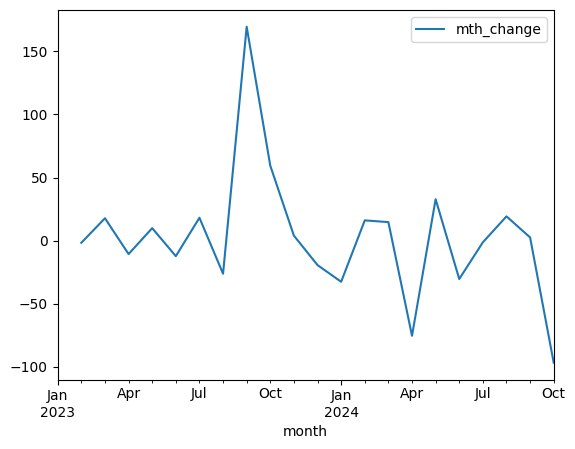

In [130]:
saless.plot(kind='line')
